**Scikit-learn Library**

Scikit-learn (sklearn) is a Python library for machine learning that provides tools for supervised learning, such as classification and regression, as well as unsupervised learning, including clustering and dimensionality reduction. It also offers utilities for model evaluation, selection, data preprocessing, and feature engineering. Scikit-learn allows developers to build machine learning models quickly, experiment with different algorithms easily, preprocess datasets efficiently, and evaluate model performance using various metrics. Its key advantages include a simple and consistent API, seamless integration with NumPy and Pandas, and extensive documentation with strong community support, making it a popular choice for both beginners and experienced practitioners.


**Importing Scikit-learn**

In [140]:
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model

**Linear Regression Example (Simple Dataset)**

**Creating Dataset**

In [141]:
X = np.array(range(-3, 8))
Y = np.array([3*x + 4 for x in X])

In [142]:
X

array([-3, -2, -1,  0,  1,  2,  3,  4,  5,  6,  7])

In [143]:
Y

array([-5, -2,  1,  4,  7, 10, 13, 16, 19, 22, 25])

**Check shape**

In [144]:
X.shape #1D array

(11,)

**Reshape to 2D (required for scikit-learn)**

In [145]:
X = X.reshape(-1, 1)
X.shape   # Now it is 2D

(11, 1)

**Plot the data**

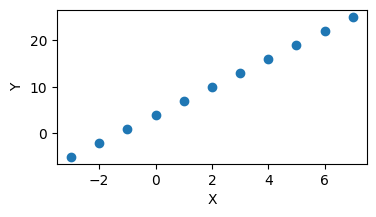

In [146]:
plt.figure(figsize=(4, 2))
plt.scatter(X, Y)
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

**Create Linear Regression Model**

In [147]:
model = linear_model.LinearRegression()

**Train the model**

In [148]:
model.fit(X, Y)

LinearRegression()

**Make Predictions (Single & Multiple Inputs)**

In [149]:
model.predict([[2]])  # Single value

array([10.])

In [150]:
model.predict([[62]])  # Another value

array([190.])

In [151]:
model.predict([[2], [12]])    # Multiple values

array([10., 40.])

In [152]:
model.predict([[2], [12], [22]])  # Multiple values

array([10., 40., 70.])

In [153]:
model.predict([[2], [5]])  # Matrix input with 1 feature per sample

array([10., 19.])

**Model Coefficients**

In [154]:
model.coef_       # Slope

array([3.])

In [155]:
model.intercept_  # Intercept

np.float64(3.9999999999999973)

**Linear Regression Example (Two Input Variables)**

**Creating Dataset**

In [156]:
X1 = np.array(range(-2, 3))
X2 = np.array([val * 2 for val in range(-2, 3)])

# Combine X1 and X2 into a 2D array
X_multi_feature = np.column_stack((X1, X2))

# Calculate Y based on both features (e.g., 3*X1 + 5*X2 + 4)
Y_multi_feature = np.array([3*x1_val + 5*x2_val + 4 for x1_val, x2_val in X_multi_feature])

print("X1:", X1)
print("X2:", X2)
print("X_multi_feature:", X_multi_feature)
print("Y_multi_feature:", Y_multi_feature)

X1: [-2 -1  0  1  2]
X2: [-4 -2  0  2  4]
X_multi_feature: [[-2 -4]
 [-1 -2]
 [ 0  0]
 [ 1  2]
 [ 2  4]]
Y_multi_feature: [-22  -9   4  17  30]


**Check Shapes**

In [157]:
print("Shape of X_multi_feature:", X_multi_feature.shape)
print("Shape of Y_multi_feature:", Y_multi_feature.shape)

Shape of X_multi_feature: (5, 2)
Shape of Y_multi_feature: (5,)


**Create and Train Linear Regression Model**

In [158]:
model_multi = linear_model.LinearRegression()
model_multi.fit(X_multi_feature, Y_multi_feature)
print("Model trained.")

Model trained.


**Make Predictions (Single & Multiple Inputs)**

In [159]:
# Predict for a single sample (X1=2, X2=4)
print("Prediction for [2, 4]:", model_multi.predict([[2, 4]]))

# Predict for multiple samples
print("Predictions for [[2, 4], [12, 24]]:", model_multi.predict([[2, 4], [12, 24]]))

Prediction for [2, 4]: [30.]
Predictions for [[2, 4], [12, 24]]: [ 30. 160.]


**Model Coefficients**

In [160]:
print("Coefficients (slopes for X1 and X2):", model_multi.coef_)
print("Intercept:", model_multi.intercept_)

Coefficients (slopes for X1 and X2): [2.6 5.2]
Intercept: 4.0


**Linear Regression on Iris Dataset**

**Load Dataset**

In [161]:
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/My Drive/Datasets For ML/Iris.csv'

iris = pd.read_csv(file_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [162]:
X = iris["PetalLengthCm"]
Y = iris["PetalWidthCm"]

**Scatter Plot of Features**

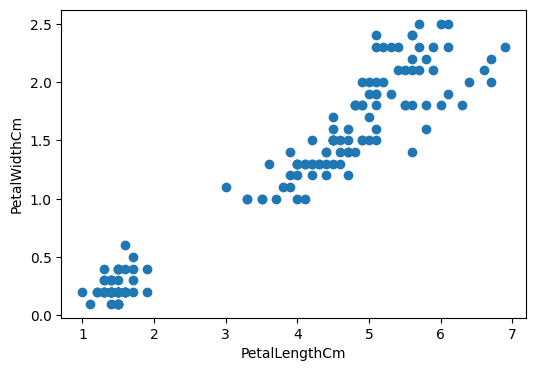

In [163]:
plt.figure(figsize=(6, 4))
plt.scatter(X, Y)
plt.xlabel("PetalLengthCm")
plt.ylabel("PetalWidthCm")
plt.show()

**Train Regression Model**

In [164]:
model_iris = linear_model.LinearRegression()

In [165]:
model_iris.fit(X.to_frame(), Y)

LinearRegression()

**Predictions**

In [166]:
model_iris.predict(pd.DataFrame([[2]], columns=['PetalLengthCm']))

array([0.46632422])

In [167]:
model_iris.predict(pd.DataFrame([[1.5]], columns=['PetalLengthCm']))

array([0.25811465])

**Plot Regression Line with Data**

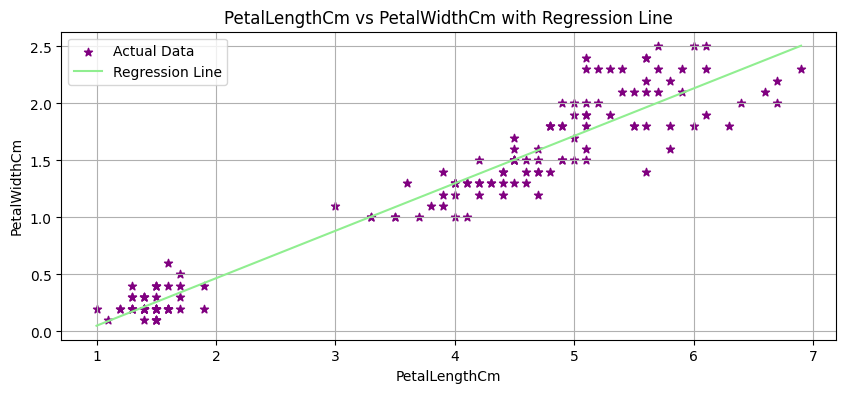

In [168]:
plt.figure(figsize=(10, 4))

plt.scatter(X, Y, marker='*', color='purple', label='Actual Data')

X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
Y_pred = model_iris.predict(pd.DataFrame(X_range, columns=['PetalLengthCm']))

plt.plot(X_range, Y_pred, color='lightgreen', label='Regression Line')
plt.xlabel('PetalLengthCm')
plt.ylabel('PetalWidthCm')
plt.title('PetalLengthCm vs PetalWidthCm with Regression Line')
plt.legend()
plt.grid(True)
plt.show()

plt.close()

**Classification Example – Logistic Regression**

**Load Iris Dataset (Features & Target)**

In [169]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

iris = pd.read_csv(file_path)

# Features (all numeric columns except target)
X = iris[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
y = iris['Species']

**Train/Test Split**

**Split dataset into training and testing sets**

In [170]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 105
Testing samples: 45


**Train Logistic Regression Model**

In [171]:
log_model = LogisticRegression(max_iter=200)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

**Predictions**

In [172]:
y_pred = log_model.predict(X_test)
y_pred[:10]  # Display first 10 predicted classes

array(['Iris-versicolor', 'Iris-setosa', 'Iris-virginica',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-setosa',
       'Iris-versicolor', 'Iris-virginica', 'Iris-versicolor',
       'Iris-versicolor'], dtype=object)

**Model Evaluation**

**Accuracy**

In [173]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


**Confusion Matrix**

In [174]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


**Classification Report**

In [175]:
report = classification_report(y_test, y_pred)
print(report)

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00        13

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45



**K-Nearest Neighbors Example (Multiple Features)**

In [176]:
from sklearn.neighbors import KNeighborsClassifier

# Use same X_train, X_test, y_train, y_test
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 1.0


**Visualization of Predictions vs Actual (Optional)**

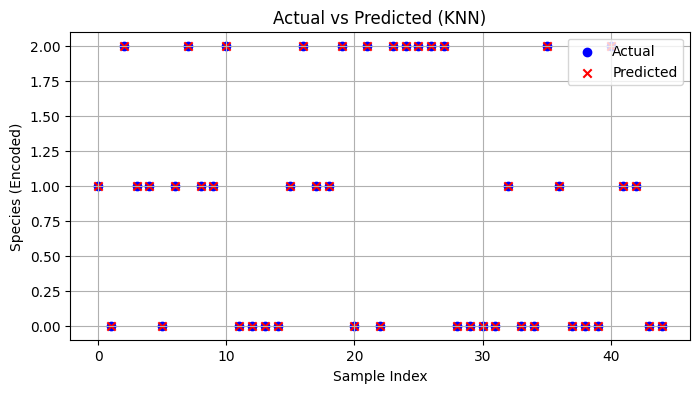

In [177]:
import matplotlib.pyplot as plt

# Compare predicted vs actual for test samples
plt.figure(figsize=(8, 4))
plt.scatter(range(len(y_test)), y_test.map({'Iris-setosa':0,'Iris-versicolor':1,'Iris-virginica':2}),
            color='blue', marker='o', label='Actual')
plt.scatter(range(len(y_pred_knn)), pd.Series(y_pred_knn).map({'Iris-setosa':0,'Iris-versicolor':1,'Iris-virginica':2}),
            color='red', marker='x', label='Predicted')
plt.xlabel('Sample Index')
plt.ylabel('Species (Encoded)')
plt.title('Actual vs Predicted (KNN)')
plt.legend()
plt.grid(True)
plt.show()
plt.close()